# Fundamentos de estadística para la analítica de datos
## Sesión 4 · La distribución de una variable I: elegir el gráfico

**Maestría en Analítica de Datos — Universidad Central**
Grupo 4M · Profesora: Diana Angélica Pulido · Periodo 2026-2
Jueves 3 de septiembre de 2026 · presencial

---

### La idea de hoy, en una frase

> **El gráfico no se elige por gusto. Se elige por el tipo de variable y por la pregunta.**

Hasta ahora los gráficos aparecieron como ilustración. Hoy son el tema. Vamos a recorrer
**once formas distintas de dibujar una sola variable** y, para cada una, responder siempre
lo mismo: qué pregunta contesta, cuándo se usa, cuándo no, y cuál es el error que casi todo
el mundo comete con ella.

Las medidas numéricas —media, mediana, desviación— entran al final, y entran como lo que
son: **el complemento que confirma o desmiente lo que el ojo creyó ver**.

### Al final de esta sesión vas a poder

1. Elegir el gráfico correcto a partir del **tipo de variable** y de la **pregunta**.
2. Justificar por qué un gráfico de barras se ordena de una forma si la variable es nominal
   y de otra si es ordinal.
3. Explicar por qué el histograma **no es un objeto**, sino una decisión: la del ancho de
   sus barras.
4. Saber qué muestra y qué **esconde** un diagrama de caja, y cuándo eso importa.
5. Leer una función de distribución acumulada, el gráfico que responde preguntas que los
   demás no pueden.
6. Calcular las medidas de centro y dispersión, y **decir cuál usar en cada forma**.

### 📌 Hoy hay Actividad 3 (4 %)

Un cuestionario corto al final de la sesión: te doy gráficos y variables, y eliges cuál va
con cuál y por qué. Se responde en clase.

---
# Preparación

Hoy trabajamos con **`diamonds`**: 53.940 diamantes con su precio, su peso y tres
clasificaciones de calidad. Es una base **ya limpia** — sin faltantes y con los tipos
correctos. Es deliberado: hoy no gastamos un minuto limpiando.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- Estilo visual del curso (el mismo de las sesiones anteriores) ---
AZUL, NARANJA, VERDE = "#2a78d6", "#eb6834", "#1baf7a"
TINTA, TINTA2, TENUE = "#0b0b0b", "#52514e", "#898781"
GRIS = "#c9ccd1"

plt.rcParams.update({
    "figure.figsize": (9, 5), "figure.dpi": 110,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": TINTA,
    "axes.titlelocation": "left", "axes.titlepad": 12,
    "axes.labelsize": 11, "axes.labelcolor": TINTA2,
    "xtick.color": TENUE, "ytick.color": TENUE,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.8,
    "legend.frameon": False, "font.size": 11,
})
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)

try:
    import seaborn as sns
    df = sns.load_dataset("diamonds")
except Exception:
    df = pd.read_csv("https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv")

print("Diamantes:", f"{df.shape[0]:,}".replace(",", "."), "| Variables:", df.shape[1])
print("Valores faltantes:", int(df.isna().sum().sum()))
df.head()

Diamantes: 53.940 | Variables: 10
Valores faltantes: 0


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


### El orden de las categorías no está en los datos: lo traes tú

`cut`, `color` y `clarity` son **cualitativas ordinales**, pero el archivo no sabe en qué
orden van. `Ideal` es mejor que `Premium`, y `IF` es mejor que `SI2`, pero eso es
conocimiento del negocio de los diamantes, no del CSV.

Declararlo explícitamente es lo primero que hay que hacer, y va a decidir cómo se dibujan
todos los gráficos del bloque 1.

In [4]:
ORDEN_CUT     = ["Fair", "Good", "Very Good", "Premium", "Ideal"]          # peor -> mejor
ORDEN_COLOR   = ["J", "I", "H", "G", "F", "E", "D"]                       # peor -> mejor
ORDEN_CLARITY = ["I1", "SI2", "SI1", "VS2", "VS1", "VVS2", "VVS1", "IF"]  # peor -> mejor

for col, orden in [("cut", ORDEN_CUT), ("color", ORDEN_COLOR), ("clarity", ORDEN_CLARITY)]:
    df[col] = pd.Categorical(df[col], categories=orden, ordered=True)

print("Tipos de variable en esta base:\n")
tipos = pd.DataFrame({
    "columna": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "tipo estadístico": ["cuantitativa continua", "cualitativa ORDINAL", "cualitativa ORDINAL",
                         "cualitativa ORDINAL", "cuantitativa continua", "cuantitativa continua",
                         "cuantitativa continua", "cuantitativa continua",
                         "cuantitativa continua", "cuantitativa continua"],
}).set_index("columna")
tipos

Tipos de variable en esta base:



,dtype,tipo estadístico
columna,,
carat,float64,cuantitativa continua
cut,category,cualitativa ORDINAL
color,category,cualitativa ORDINAL
clarity,category,cualitativa ORDINAL
depth,float64,cuantitativa continua
table,float64,cuantitativa continua
price,int64,cuantitativa continua
x,float64,cuantitativa continua
y,float64,cuantitativa continua


---
# 0 · El mapa: qué gráfico para qué

Antes de dibujar nada, la tabla que hay que tener en la cabeza. Se lee de izquierda a
derecha: **primero el tipo de variable, después la pregunta**. El gráfico es la última
columna, no la primera.

| Tipo | La pregunta | El gráfico |
|---|---|---|
| **Cualitativa** | ¿Cuántos hay de cada categoría? | **Barras** |
| | ¿Qué proporción del total es cada una? | Barras (con eje en %) |
| | ¿Unas pocas categorías concentran casi todo? | **Pareto** |
| | ¿Hay muchas categorías y quiero compararlas? | **Lollipop** o barras horizontales |
| **Cuantitativa** | ¿Qué forma tiene la distribución? | **Histograma** |
| | ¿Cuál es la forma, sin decidir el ancho de las barras? | **Densidad** |
| | ¿Dónde están el centro y la dispersión, de un vistazo? | **Diagrama de caja** |
| | ¿Forma y resumen a la vez? | **Violín** |
| | ¿Cómo se ve cada observación? (pocos datos) | **Puntos con jitter** |
| | ¿Qué proporción está por debajo de un valor? | **Acumulada (ECDF)** |

> **Los dos errores que se cometen al revés.** Uno: elegir el gráfico primero y buscarle
> después una pregunta. Dos: usar el mismo gráfico para todo porque es el que uno sabe
> hacer.

Cada gráfico de hoy viene con una ficha de cuatro campos. **Léela antes de mirar el
dibujo.**

---
---
# Bloque 1 · Variables cualitativas

Cinco formas de dibujar una variable categórica, en orden de utilidad real.

## 1 · El gráfico de barras

| | |
|---|---|
| **Qué responde** | ¿Cuántas observaciones hay en cada categoría? ¿Cuál es la más frecuente? |
| **Cuándo usarlo** | Siempre que la variable sea cualitativa. Es el gráfico por defecto, y casi nunca es el equivocado. |
| **Cuándo NO** | Si las categorías son más de 15 – 20: pasa a barras horizontales o a un lollipop. |
| **El error frecuente** | Empezar el eje en un valor distinto de cero. En barras **la longitud es el dato**: si el eje no empieza en cero, la longitud miente. |

Empecemos por `cut`, la calidad del tallado.

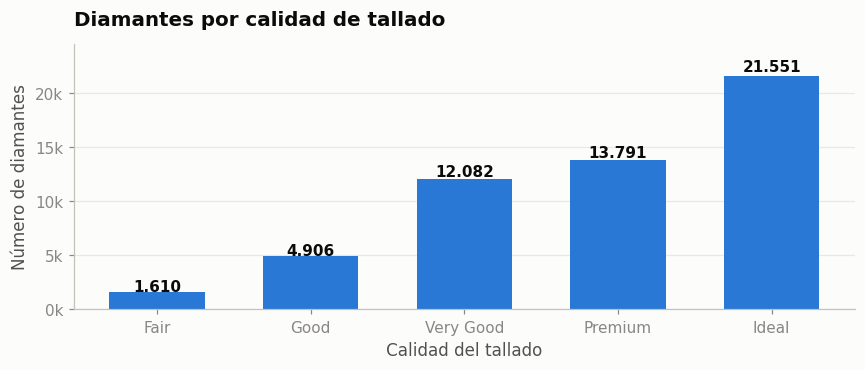

In [5]:
conteo = df["cut"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(conteo.index.astype(str), conteo.values, color=AZUL, width=0.62)

ax.set_title("Diamantes por calidad de tallado")
ax.set_xlabel("Calidad del tallado")
ax.set_ylabel("Número de diamantes")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"{y/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7)
ax.set_axisbelow(True)

for i, v in enumerate(conteo.values):
    ax.text(i, v * 1.02, f"{v:,}".replace(",", "."), ha="center",
            fontsize=10, color=TINTA, fontweight="bold")
ax.set_ylim(0, conteo.max() * 1.14)

plt.tight_layout()
plt.show()

🔍 **Lo que hay que leer aquí.** Los diamantes de tallado `Ideal` son casi la mitad de la
base, y los `Fair` son marginales. Pero fíjate en algo más importante: **las barras están
en el orden natural de la variable**, de peor a mejor tallado, y eso permite ver que la
frecuencia crece con la calidad. Ese patrón se perdería con cualquier otro orden.

## 2 · El orden de las barras: la decisión que casi nadie piensa

Esta es la diferencia entre un gráfico correcto y uno que confunde, y depende de **una sola
cosa**: si la variable es nominal u ordinal.

| Si la variable es… | Se ordena… | Por qué |
|---|---|---|
| **Nominal** (ciudad, canal, marca) | De mayor a menor frecuencia | No hay orden natural, así que el orden lo pone la magnitud: facilita comparar |
| **Ordinal** (estrato, calidad, nivel) | Por su orden natural | El orden **es información**. Reordenar por frecuencia la destruye |

Veámoslo con la misma variable, dibujada de las dos formas.

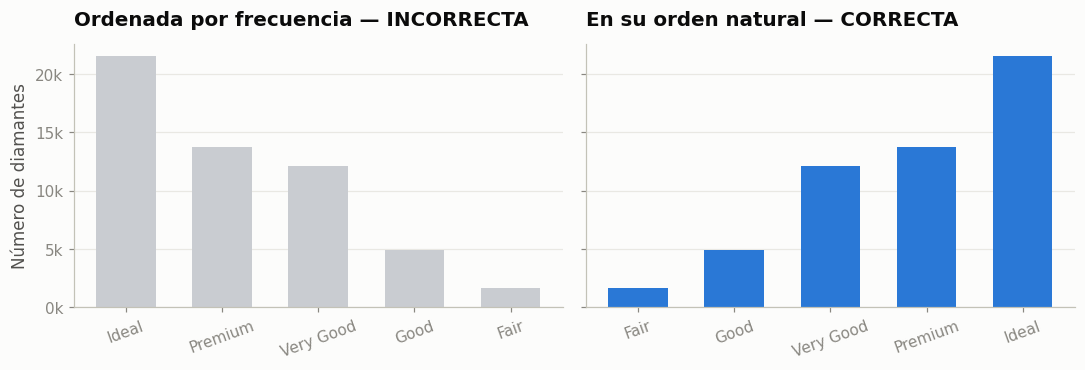

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)

# --- Izquierda: ordenada por frecuencia (lo que haría un gráfico automático)
frec = df["cut"].value_counts()
ax1.bar(frec.index.astype(str), frec.values, color=GRIS, width=0.62)
ax1.set_title("Ordenada por frecuencia — INCORRECTA")
ax1.set_ylabel("Número de diamantes")

# --- Derecha: en su orden natural
nat = df["cut"].value_counts().sort_index()
ax2.bar(nat.index.astype(str), nat.values, color=AZUL, width=0.62)
ax2.set_title("En su orden natural — CORRECTA")

for ax in (ax1, ax2):
    ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"{y/1000:,.0f}k".replace(",", ".")))

plt.tight_layout()
plt.show()

🔍 **Mira los dos y pregúntate qué historia cuenta cada uno.**

A la izquierda ves un ranking: cuál es el más frecuente. A la derecha ves una **tendencia**:
a mejor tallado, más diamantes. La segunda lectura es imposible en el gráfico de la
izquierda, y es la interesante.

> **La regla:** en una variable ordinal, el eje ya tiene un significado. Reordenarlo por
> frecuencia es como ordenar los meses del año por número de ventas — se pierde el eje del
> tiempo.

Y al revés: en una nominal, dejar el orden alfabético o el orden en que vino el archivo es
igual de arbitrario que cualquier otro, y ordenar por frecuencia sí ayuda.

## 3 · El gráfico de torta

| | |
|---|---|
| **Qué responde** | ¿Qué proporción del total representa cada categoría? |
| **Cuándo usarlo** | Con **dos o tres categorías**, y cuando lo único que importa es «esto es más o menos la mitad». |
| **Cuándo NO** | Con más de tres categorías, o cuando haya que comparar tamaños parecidos entre sí. |
| **El error frecuente** | Usarlo por costumbre. El ojo humano compara longitudes bien y **ángulos mal**: dos porciones de 22 % y 25 % son indistinguibles. |

La forma honesta de decidir es comparar los dos gráficos con los mismos datos.

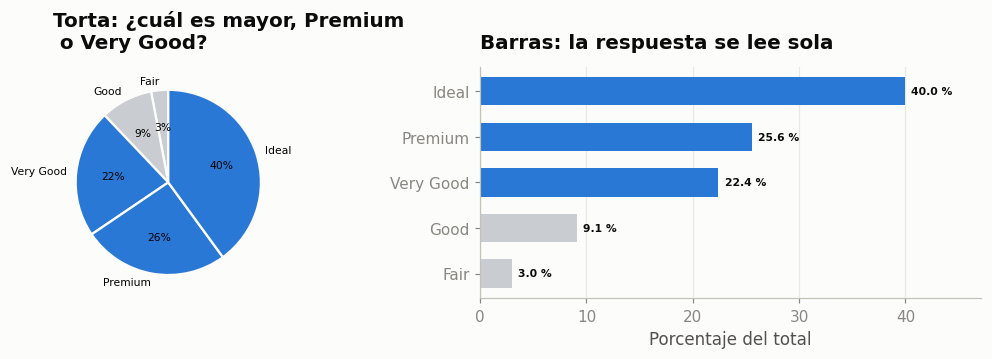

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

prop = (df["cut"].value_counts().sort_index() / len(df) * 100)
colores = [GRIS, GRIS, AZUL, AZUL, AZUL]

ax1.pie(prop.values, labels=[str(c) for c in prop.index], autopct="%1.0f%%",
        colors=colores, startangle=90, textprops={"fontsize": 7},
        wedgeprops={"edgecolor": "#fcfcfb", "linewidth": 1.5})
ax1.set_title("Torta: ¿cuál es mayor, Premium \n o Very Good?")

ax2.barh(prop.index.astype(str), prop.values, color=colores, height=0.62)
ax2.set_title("Barras: la respuesta se lee sola")
ax2.set_xlabel("Porcentaje del total")
ax2.grid(axis="x", alpha=0.7); ax2.set_axisbelow(True)
for i, v in enumerate(prop.values):
    ax2.text(v + 0.6, i, f"{v:.1f} %", va="center", fontsize=7, fontweight="bold", color=TINTA)
ax2.set_xlim(0, prop.max() * 1.18)

plt.tight_layout()
plt.show()

🔍 **Haz el experimento en serio.** Tápate la parte de la derecha y mira solo la torta:
¿cuál es mayor, `Premium` o `Very Good`? La diferencia real es de poco más de **tres puntos
porcentuales** —25,6 % contra 22,4 %— y en ángulos es invisible sin leer las etiquetas.

Si el gráfico necesita que le escribas los números encima para poder leerse, **el gráfico no
está haciendo su trabajo**: es una tabla disfrazada.

> **Cuándo la torta sí sirve.** «El 68 % de nuestros clientes son nuevos.» Dos categorías,
> una comparación contra la mitad, y el mensaje es la proporción, no el ranking.

## 4 · El diagrama de Pareto

| | |
|---|---|
| **Qué responde** | ¿Unas pocas categorías concentran la mayor parte del total? ¿Cuántas necesito para cubrir el 80 %? |
| **Cuándo usarlo** | Cuando hay que **priorizar**: qué causas atacar primero, qué productos concentran las ventas, qué fallas explican la mayoría de las devoluciones. |
| **Cuándo NO** | Cuando las categorías están repartidas de forma pareja: el gráfico no dirá nada útil. |
| **El error frecuente** | Olvidar la línea acumulada. Sin ella es solo un gráfico de barras ordenado. |

Lo aplicamos a `clarity`, la pureza del diamante, que tiene ocho categorías.

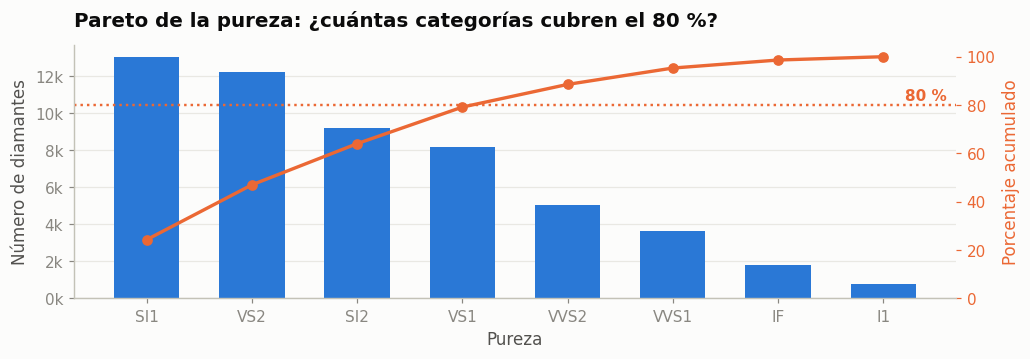

Categorías necesarias para superar el 80 % del total: 5 de 8


In [8]:
frec = df["clarity"].value_counts().sort_values(ascending=False)
acum = frec.cumsum() / frec.sum() * 100

fig, ax = plt.subplots(figsize=(9.5, 3.4))
ax.bar(frec.index.astype(str), frec.values, color=AZUL, width=0.62)
ax.set_ylabel("Número de diamantes")
ax.set_xlabel("Pureza")
ax.set_title("Pareto de la pureza: ¿cuántas categorías cubren el 80 %?")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"{y/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

ax2 = ax.twinx()
ax2.plot(frec.index.astype(str), acum.values, color=NARANJA, marker="o",
         linewidth=2.2, markersize=6)
ax2.axhline(80, color=NARANJA, linestyle=":", linewidth=1.6)
ax2.text(len(frec) - 0.4, 82, "80 %", color=NARANJA, fontsize=10, fontweight="bold", ha="right")
ax2.set_ylabel("Porcentaje acumulado", color=NARANJA)
ax2.set_ylim(0, 105)
ax2.tick_params(axis="y", colors=NARANJA)
ax2.grid(False)

plt.tight_layout()
plt.show()

print("Categorías necesarias para superar el 80 % del total:",
      int((acum < 80).sum()) + 1, "de", len(frec))

🔍 **Para qué sirve de verdad.** La barra dice cuánto hay; la línea dice **cuánto llevas
acumulado**. La pregunta que responde no es «¿cuál es la más común?» sino «¿en cuántas me
tengo que concentrar para cubrir la mayoría?».

Es el gráfico de las decisiones de priorización: si cuatro de ocho categorías explican el
80 % del volumen, ya sabes dónde poner el esfuerzo.

## 5 · El lollipop

| | |
|---|---|
| **Qué responde** | Lo mismo que las barras, pero cuando hay muchas categorías o los nombres son largos. |
| **Cuándo usarlo** | Con 8 o más categorías, o con etiquetas que no caben en horizontal. |
| **Cuándo NO** | Cuando las diferencias son pequeñas: la línea fina las hace más difíciles de comparar que una barra sólida. |
| **El error frecuente** | Ninguno grave. Es una barra con menos tinta — la misma información con menos ruido visual. |



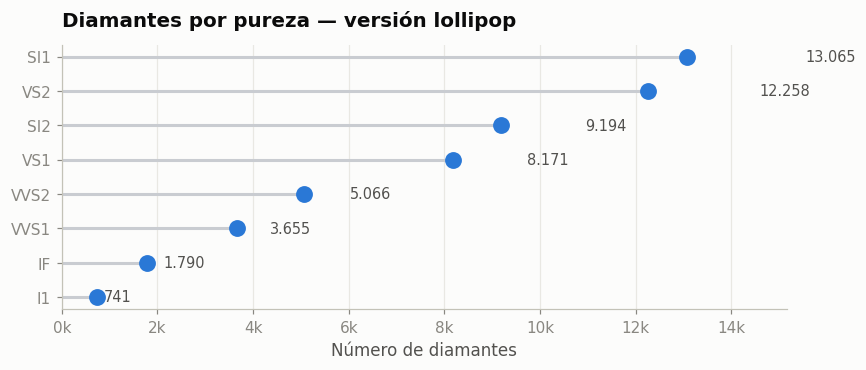

In [9]:
frec = df["clarity"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hlines(y=frec.index.astype(str), xmin=0, xmax=frec.values, color=GRIS, linewidth=2)
ax.plot(frec.values, frec.index.astype(str), "o", markersize=10, color=AZUL)

ax.set_title("Diamantes por pureza — versión lollipop")
ax.set_xlabel("Número de diamantes")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"{x/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="x", alpha=0.7); ax.set_axisbelow(True)
for i, v in enumerate(frec.values):
    ax.text(v * 1.19, i, f"{v:,}".replace(",", "."), va="center", fontsize=9.5, color=TINTA2)
ax.set_xlim(0, frec.max() * 1.16)

plt.tight_layout()
plt.show()

> **La idea de fondo, que vale para todo el curso:** entre dos gráficos que dicen lo mismo,
> gana el que usa menos tinta. Cada elemento que dibujas debe ganarse su lugar.

---
---
# Bloque 2 · Variables cuantitativas

Seis formas de dibujar una variable numérica. La elección ya no es «barras o torta»: es
**qué aspecto de la distribución quiero ver**.

Trabajamos con `price`, el precio en dólares.

## 6 · El histograma

| | |
|---|---|
| **Qué responde** | ¿Qué forma tiene la distribución? ¿Dónde se concentran los datos? ¿Es simétrica? ¿Tiene una o varias modas? |
| **Cuándo usarlo** | Es el gráfico por defecto de una variable cuantitativa. El primero que se dibuja, siempre. |
| **Cuándo NO** | Con muy pocos datos (menos de 30 – 50): el resultado depende demasiado del azar. |
| **El error frecuente** | Aceptar el número de barras que el programa eligió por ti. **El histograma no es un objeto: es una decisión.** |



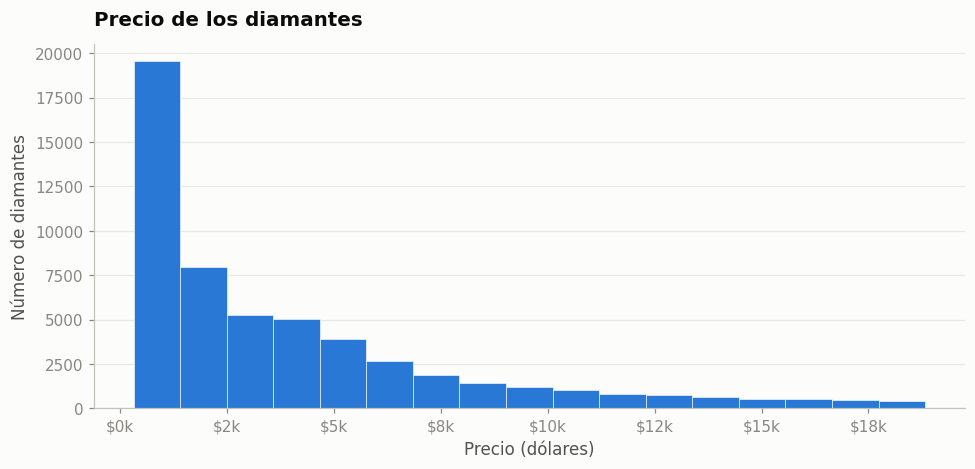

In [31]:
precio = df["price"]

fig, ax = plt.subplots(figsize=(9, 4.4))
ax.hist(precio, bins=17, color=AZUL, edgecolor="#fcfcfb", linewidth=0.4)

ax.set_title("Precio de los diamantes")
ax.set_xlabel("Precio (dólares)")
ax.set_ylabel("Número de diamantes")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### 6.1 · El número de barras lo cambia todo

Este es **el punto más importante del bloque**. Los cuatro paneles de abajo son la misma
variable, los mismos 53.940 diamantes. Lo único que cambia es en cuántas barras se reparten.

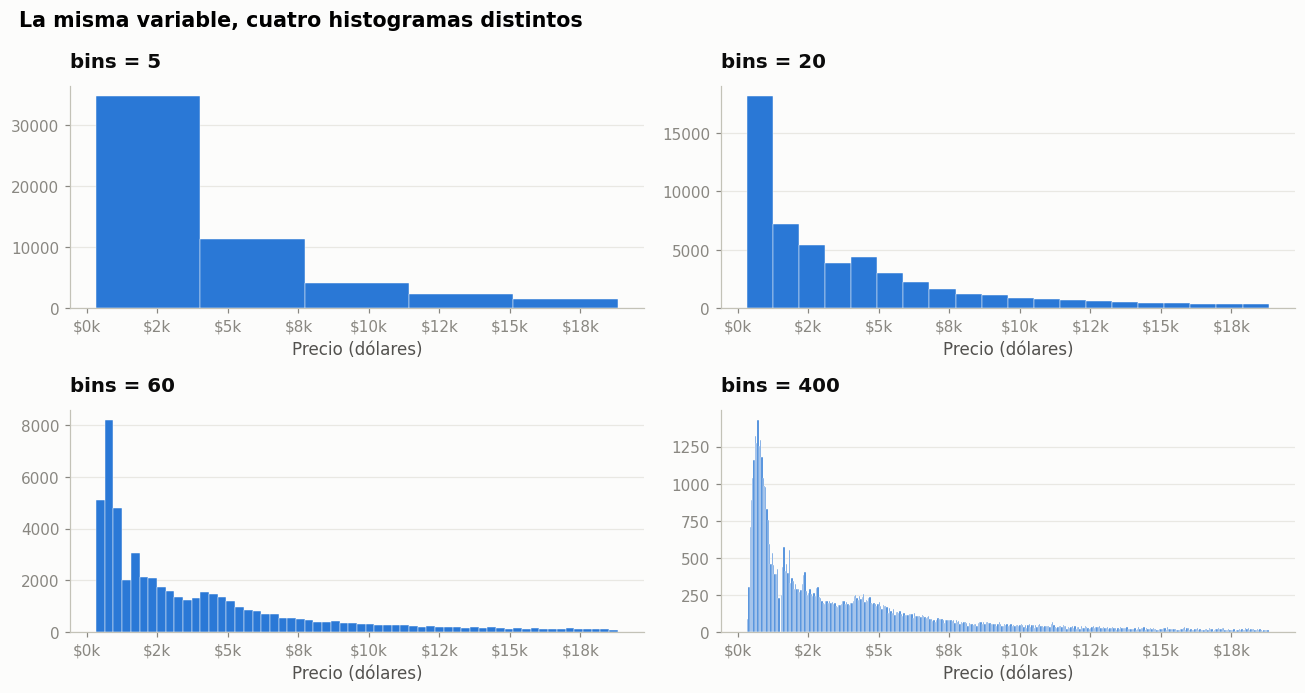

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 6.4))
for ax, b in zip(axes.flat, [5, 20, 60, 400]):
    ax.hist(precio, bins=b, color=AZUL, edgecolor="#fcfcfb", linewidth=0.3)
    ax.set_title(f"bins = {b}")
    ax.set_xlabel("Precio (dólares)")
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
    ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

fig.suptitle("La misma variable, cuatro histogramas distintos",
             fontsize=13.5, fontweight="bold", x=0.02, ha="left")
plt.tight_layout()
plt.show()

🔍 **Qué se pierde y qué se inventa en cada uno**

| bins | Qué pasa |
|---|---|
| **5** | Tan grueso que solo se ve «hay más baratos que caros». Se pierde toda la estructura |
| **20** | Se ve la forma general: pico a la izquierda, cola larga a la derecha |
| **60** | Aparece el detalle real: el pico no es liso, tiene estructura |
| **400** | El ruido empieza a competir con la señal: cada barra tiene pocos datos |

> **La regla práctica.** Prueba al menos tres anchos antes de quedarte con uno. Si un rasgo
> —un segundo pico, un hueco— **aparece con unos anchos y desaparece con otros**, no confíes
> en él todavía. Si sobrevive a todos, es real.

Existen reglas automáticas (Sturges, Freedman-Diaconis) y `bins="auto"` las aplica. Sirven
como punto de partida, **no como respuesta final**.

### Las tres reglas, con su fórmula

Ninguna de las tres adivina la respuesta: proponen un punto de partida a partir del tamaño de
la muestra y de la dispersión.

**Sturges** — solo mira cuántos datos hay. Fija directamente el **número** de barras:

$$k = \lceil \log_2 n \rceil + 1$$

Es la más antigua y la más optimista: supone que los datos son aproximadamente normales, así
que en distribuciones con cola larga se queda corta.

**Freedman-Diaconis** — mira la dispersión del 50 % central. Fija el **ancho** de cada barra:

$$h = 2 \cdot \frac{\text{RIC}}{\sqrt[3]{n}}
\qquad \text{y de ahí} \qquad
k = \left\lceil \frac{\text{máx} - \text{mín}}{h} \right\rceil$$

Al apoyarse en el RIC —que es robusto— unos pocos valores extremos no la desordenan.

**`auto`** — no es una regla nueva. `numpy` calcula las dos anteriores y **se queda con la que
propone más barras**, es decir, con el ancho más pequeño de los dos.

> **Con `price` la diferencia es enorme, y vale la pena entender por qué.** Sturges propone
> **17** barras y Freedman-Diaconis **80**. El número de Sturges depende *solo* de $n$: con
> 53.940 diamantes, $\log_2 n + 1 \approx 16{,}7$, y da lo mismo que la variable sea el precio
> o la profundidad. Freedman-Diaconis, en cambio, divide el rango completo —18.497 dólares—
> entre un ancho calculado con el RIC, que es de 4.374: al no dejarse estirar por la cola,
> acaba proponiendo barras mucho más finas.


In [29]:
# Lo que proponen las reglas automáticas para esta variable
for regla in ["sturges", "fd", "auto"]:
    n_bins = len(np.histogram_bin_edges(precio, bins=regla)) - 1
    print(f"{regla:10s} -> {n_bins:4d} barras")

sturges    ->   17 barras
fd         ->   80 barras
auto       ->   80 barras


## 7 · La curva de densidad

| | |
|---|---|
| **Qué responde** | La misma pregunta del histograma —¿qué forma tiene?— pero sin tener que elegir el ancho de las barras. |
| **Cuándo usarlo** | Para ver la forma limpia, y sobre todo para **comparar varias distribuciones en el mismo eje**: dos histogramas superpuestos se estorban, dos curvas no. |
| **Cuándo NO** | Con variables acotadas: la curva se sale del límite. Si el precio no puede ser negativo, la densidad igual dibujará algo a la izquierda del cero. |
| **El error frecuente** | Creer que la curva es «los datos». Es una **estimación suavizada**, y el suavizado también es una decisión. |



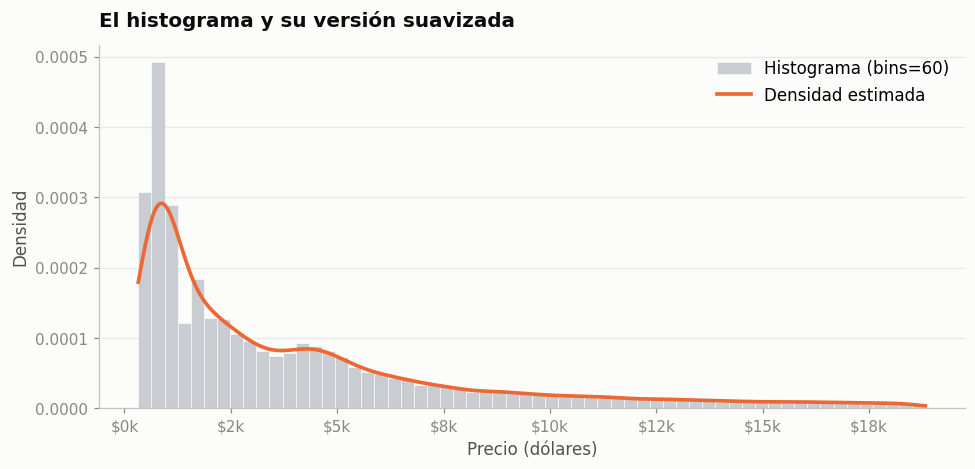

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.4))

ax.hist(precio, bins=60, density=True, color=GRIS, edgecolor="#fcfcfb",
        linewidth=0.4, label="Histograma (bins=60)")

rejilla = np.linspace(precio.min(), precio.max(), 600)
kde = stats.gaussian_kde(precio)
ax.plot(rejilla, kde(rejilla), color=NARANJA, linewidth=2.4, label="Densidad estimada")

ax.set_title("El histograma y su versión suavizada")
ax.set_xlabel("Precio (dólares)")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

### 7.1 · El suavizado también es una decisión

El histograma tenía el número de barras; la densidad tiene el **ancho de banda**. Y hace
exactamente el mismo daño si se elige mal.

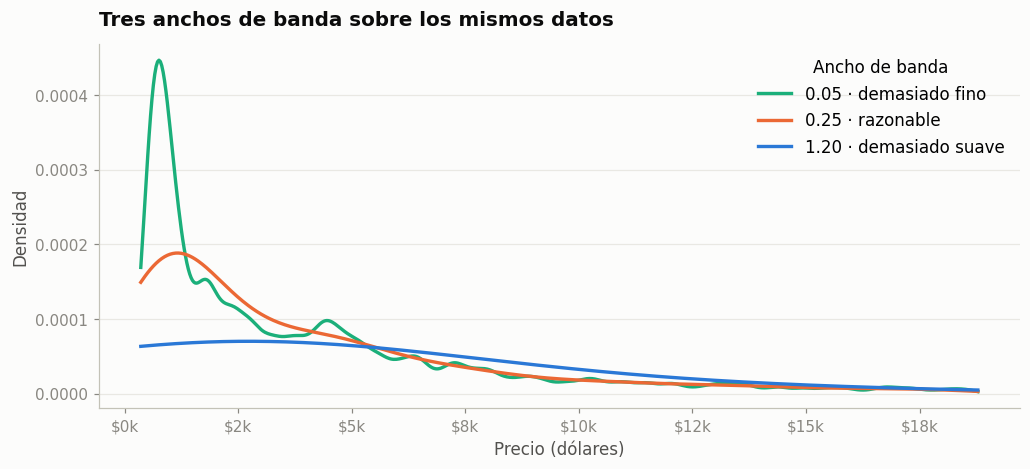

In [14]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))

muestra = precio.sample(4000, random_state=7).values
rejilla = np.linspace(muestra.min(), muestra.max(), 600)

for bw, color, etiqueta in [(0.05, VERDE, "0.05 · demasiado fino"),
                            (0.25, NARANJA, "0.25 · razonable"),
                            (1.20, AZUL, "1.20 · demasiado suave")]:
    ax.plot(rejilla, stats.gaussian_kde(muestra, bw_method=bw)(rejilla),
            color=color, linewidth=2.2, label=etiqueta)

ax.set_title("Tres anchos de banda sobre los mismos datos")
ax.set_xlabel("Precio (dólares)")
ax.set_ylabel("Densidad")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)
ax.legend(title="Ancho de banda", loc="upper right")

plt.tight_layout()
plt.show()

🔍 **Los dos fracasos simétricos.** Con un ancho demasiado fino la curva persigue el ruido
y aparecen picos que no existen. Con uno demasiado ancho se aplana todo y desaparecen
rasgos que sí existen.

> **Histograma o densidad, ¿cuál?** Histograma para explorar tú, porque es honesto: se ve
> dónde están los datos. Densidad para comparar grupos o para presentar, porque es limpia.
> Y en un informe, **las dos juntas** son mejor que cualquiera de las dos sola.

## 8 · El diagrama de caja

| | |
|---|---|
| **Qué responde** | ¿Dónde está el centro, cuán dispersos están los datos y hay valores extremos? Todo en un dibujo que ocupa una línea. |
| **Cuándo usarlo** | Sobre todo para **comparar muchos grupos a la vez**. Ahí no tiene rival: veinte cajas en un gráfico se leen; veinte histogramas, no. |
| **Cuándo NO** | Cuando lo que importa es la **forma** de una sola distribución. Para eso está el histograma. |
| **El error frecuente** | Creer que resume la distribución. Resume **cinco números** de la distribución, que no es lo mismo. |

El diagrama de caja es los cinco números hechos dibujo. Vale la pena verlo desarmado.

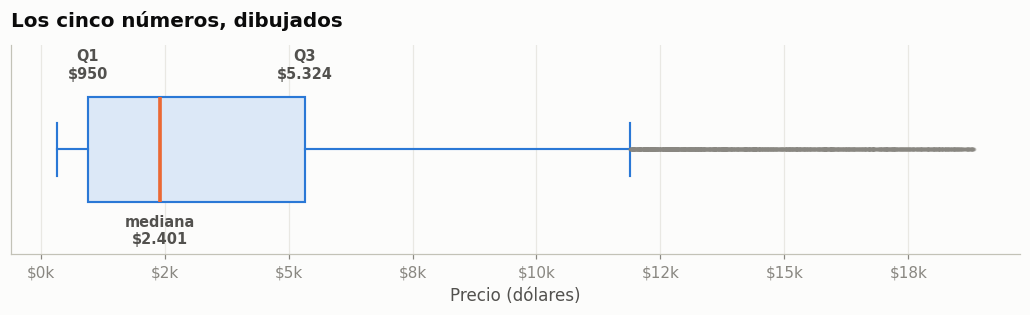

Q1 = $950  | mediana = $2.401  | Q3 = $5.324
Rango intercuartílico (RIC) = $4.374
Vallas de Tukey: $0  a  $11.886


In [15]:
q1, mediana, q3 = precio.quantile([0.25, 0.50, 0.75])
ric = q3 - q1
valla_inf, valla_sup = q1 - 1.5 * ric, q3 + 1.5 * ric

fig, ax = plt.subplots(figsize=(9.5, 3.0))
ax.boxplot(precio, vert=False, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#dce8f7", edgecolor=AZUL, linewidth=1.4),
           medianprops=dict(color=NARANJA, linewidth=2.4),
           whiskerprops=dict(color=AZUL, linewidth=1.4),
           capprops=dict(color=AZUL, linewidth=1.4),
           flierprops=dict(marker="o", markersize=2.5, markerfacecolor=TENUE,
                           markeredgecolor="none", alpha=0.25))

for x, etq, dy in [(q1, f"Q1\n${q1:,.0f}", 1.34), (mediana, f"mediana\n${mediana:,.0f}", 0.55),
                   (q3, f"Q3\n${q3:,.0f}", 1.34)]:
    ax.annotate(etq.replace(",", "."), xy=(x, 1), xytext=(x, dy), ha="center",
                fontsize=9.5, fontweight="bold", color=TINTA2)

ax.set_title("Los cinco números, dibujados")
ax.set_xlabel("Precio (dólares)")
ax.set_yticks([])
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="x", alpha=0.7); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Q1 = ${q1:,.0f}".replace(",", "."),
      f" | mediana = ${mediana:,.0f}".replace(",", "."),
      f" | Q3 = ${q3:,.0f}".replace(",", "."))
print(f"Rango intercuartílico (RIC) = ${ric:,.0f}".replace(",", "."))
print(f"Vallas de Tukey: ${max(valla_inf,0):,.0f}  a  ${valla_sup:,.0f}".replace(",", "."))

### 8.1 · Donde el diagrama de caja es imbatible

Una caja sola dice poco. **Veinte cajas juntas dicen muchísimo**, y ese es su verdadero
oficio: comparar la distribución de una variable entre grupos.

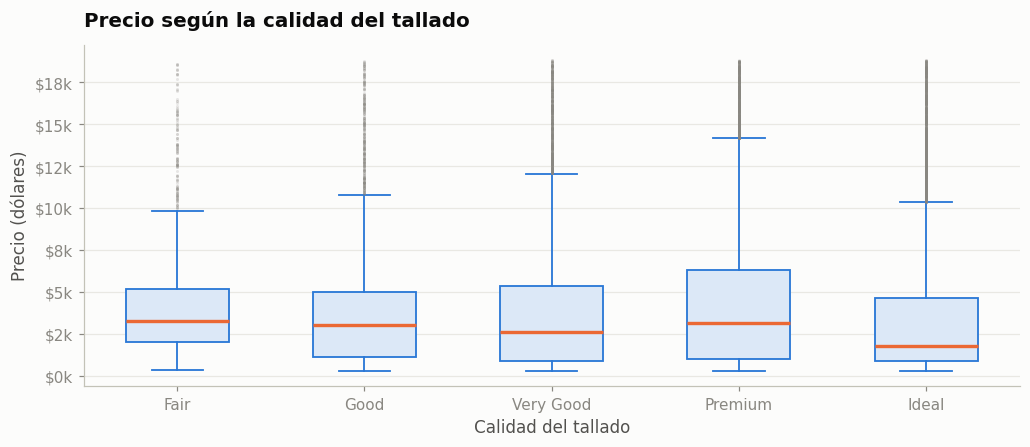

In [16]:
grupos = [df.loc[df["cut"] == c, "price"].values for c in ORDEN_CUT]

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bp = ax.boxplot(grupos, vert=True, widths=0.55, patch_artist=True,
                boxprops=dict(facecolor="#dce8f7", edgecolor=AZUL, linewidth=1.2),
                medianprops=dict(color=NARANJA, linewidth=2.2),
                whiskerprops=dict(color=AZUL, linewidth=1.2),
                capprops=dict(color=AZUL, linewidth=1.2),
                flierprops=dict(marker="o", markersize=2, markerfacecolor=TENUE,
                                markeredgecolor="none", alpha=0.18))

ax.set_xticks(range(1, len(ORDEN_CUT) + 1))
ax.set_xticklabels(ORDEN_CUT)
ax.set_title("Precio según la calidad del tallado")
ax.set_xlabel("Calidad del tallado")
ax.set_ylabel("Precio (dólares)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${y/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

🔍 **Y aquí aparece algo que no esperábamos.** Los diamantes de **mejor** tallado son los
**más baratos**. La mediana de un `Ideal` es de USD 1.810; la de un `Fair`, USD 3.282. Casi el
doble, en el sentido contrario al que dicta el sentido común.

No lo resolvemos hoy —la explicación tiene que ver con el peso, y con una variable que se
esconde detrás— pero **anótalo**: es exactamente el tipo de hallazgo que aparece al mirar y
que ningún promedio general habría revelado. Volvemos a él en la sesión 6.

## 9 · El violín

| | |
|---|---|
| **Qué responde** | Forma **y** resumen a la vez: la densidad de la distribución con la caja adentro. |
| **Cuándo usarlo** | Cuando comparas grupos y sospechas que la forma importa — que puede haber dos picos, o distribuciones muy distintas con la misma mediana. |
| **Cuándo NO** | Con audiencias no técnicas: hay que explicar cómo se lee. Y con pocos datos por grupo, la forma es pura invención del suavizado. |
| **El error frecuente** | Olvidar que el ancho del violín es una densidad estimada, con su ancho de banda y sus problemas. |



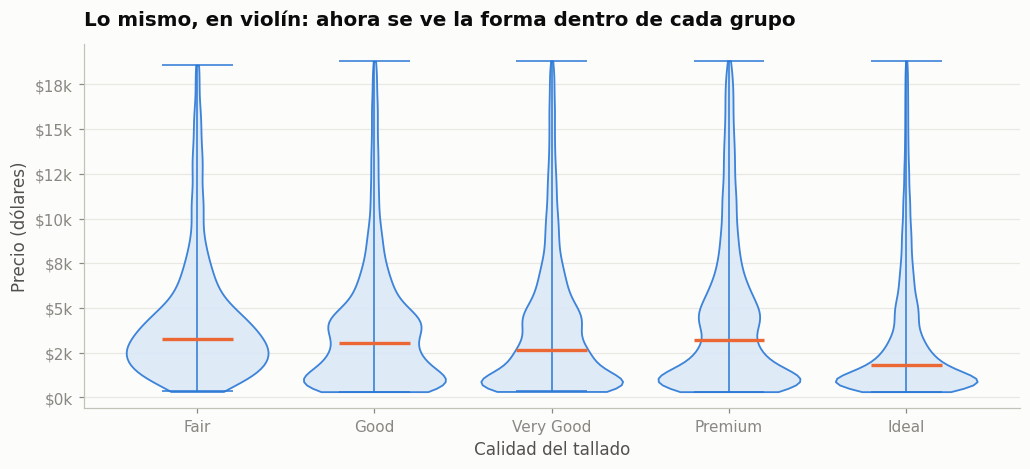

In [17]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))

vp = ax.violinplot(grupos, showmedians=True, widths=0.8)
for cuerpo in vp["bodies"]:
    cuerpo.set_facecolor("#dce8f7"); cuerpo.set_edgecolor(AZUL)
    cuerpo.set_alpha(0.9); cuerpo.set_linewidth(1.2)
for clave in ("cmedians", "cmaxes", "cmins", "cbars"):
    if clave in vp:
        vp[clave].set_color(NARANJA if clave == "cmedians" else AZUL)
        vp[clave].set_linewidth(2.2 if clave == "cmedians" else 1.0)

ax.set_xticks(range(1, len(ORDEN_CUT) + 1))
ax.set_xticklabels(ORDEN_CUT)
ax.set_title("Lo mismo, en violín: ahora se ve la forma dentro de cada grupo")
ax.set_xlabel("Calidad del tallado")
ax.set_ylabel("Precio (dólares)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${y/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

🔍 **Lo que el violín agrega a la caja.** Todas las distribuciones están apelmazadas contra
el eje inferior y con una cola larguísima hacia arriba. Eso la caja lo insinuaba con los
bigotes; el violín lo muestra: **la masa de diamantes está en los precios bajos, en todos
los grupos**.

## 10 · Los puntos con desplazamiento

| | |
|---|---|
| **Qué responde** | ¿Cómo se ve **cada observación**? ¿Cuántas hay realmente detrás de cada resumen? |
| **Cuándo usarlo** | Con pocos datos —hasta unos 200 por grupo—. Es el gráfico más honesto que existe: no resume nada. |
| **Cuándo NO** | Con muchos datos: los puntos se apelmazan y no se ve nada. Ahí toca resumir. |
| **El error frecuente** | Dibujar los puntos sin desplazamiento lateral: quedan encimados y 50 observaciones parecen 5. |

Con 53.940 diamantes esto sería ilegible, así que tomamos una muestra pequeña — que es
justo el escenario donde este gráfico gana.

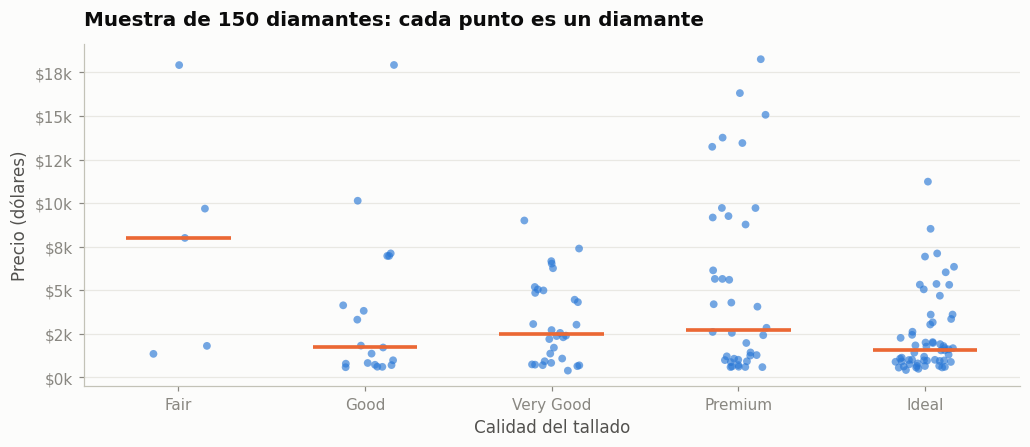

Diamantes por grupo en esta muestra:
cut
Fair          5
Good         19
Very Good    30
Premium      38
Ideal        58


In [18]:
muestra = df.sample(150, random_state=13)
rng = np.random.default_rng(4)

fig, ax = plt.subplots(figsize=(9.5, 4.2))
for i, c in enumerate(ORDEN_CUT):
    y = muestra.loc[muestra["cut"] == c, "price"].values
    x = i + rng.uniform(-0.16, 0.16, len(y))     # el desplazamiento (jitter)
    ax.scatter(x, y, s=26, color=AZUL, alpha=0.65, edgecolor="none")
    if len(y):
        ax.hlines(np.median(y), i - 0.28, i + 0.28, color=NARANJA, linewidth=2.4)

ax.set_xticks(range(len(ORDEN_CUT)))
ax.set_xticklabels(ORDEN_CUT)
ax.set_title("Muestra de 150 diamantes: cada punto es un diamante")
ax.set_xlabel("Calidad del tallado")
ax.set_ylabel("Precio (dólares)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, p: f"${y/1000:,.0f}k".replace(",", ".")))
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("Diamantes por grupo en esta muestra:")
print(muestra["cut"].value_counts().sort_index().to_string())

> **Por qué importa ver el tamaño de cada grupo.** Una caja dibujada con 6 observaciones se
> ve igual de sólida que una dibujada con 6.000, y no lo es. Los puntos lo delatan de
> inmediato. Cuando presentes cajas, **escribe siempre el `n` de cada grupo**.

## 11 · La acumulada empírica (ECDF)

| | |
|---|---|
| **Qué responde** | ¿Qué **proporción** de los datos está por debajo de un valor cualquiera? Y al revés: ¿por debajo de qué valor está el 90 %? |
| **Cuándo usarlo** | Cuando la pregunta viene con un umbral: «¿cuántos diamantes cuestan menos de 5.000?», «¿qué proporción de trámites tarda más de 30 minutos?». |
| **Cuándo NO** | Cuando lo que se busca es la forma o las modas: la ECDF las esconde, porque siempre sube. |
| **El error frecuente** | No usarla nunca. Es el gráfico más subestimado de la estadística descriptiva. |

Es el único gráfico de hoy **sin ninguna decisión arbitraria**: no hay bins, no hay ancho de
banda. Es exactamente lo que dicen los datos.

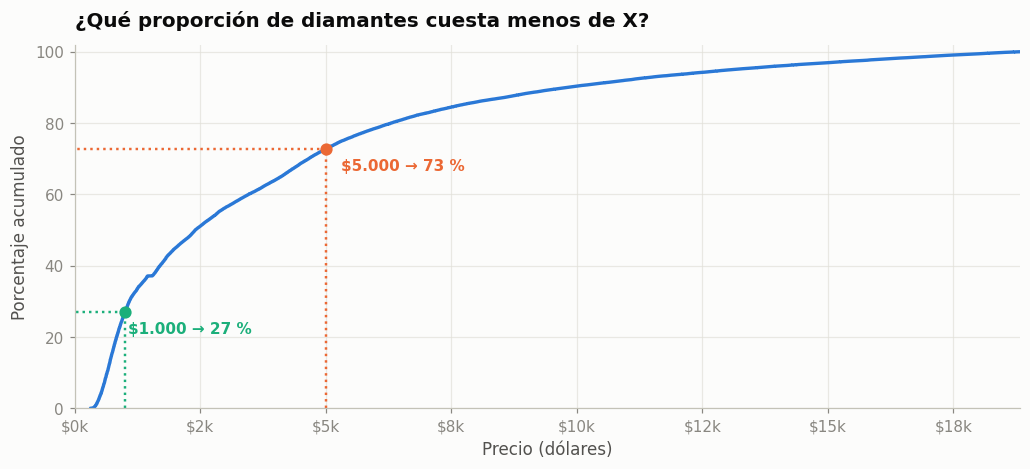

El 50 % cuesta menos de $2.401
El 90 % cuesta menos de $9.821
El 99 % cuesta menos de $17.378


In [19]:
x = np.sort(precio.values)
y = np.arange(1, len(x) + 1) / len(x) * 100

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(x, y, color=AZUL, linewidth=2.2)

# Lectura en las dos direcciones
for umbral, color in [(1000, VERDE), (5000, NARANJA)]:
    pct = (precio <= umbral).mean() * 100
    ax.plot([umbral, umbral, 0], [0, pct, pct], color=color, linestyle=":", linewidth=1.6)
    ax.plot(umbral, pct, "o", color=color, markersize=7)
    ax.text(umbral * 1.06, pct - 6, f"${umbral:,.0f} → {pct:.0f} %".replace(",", "."),
            color=color, fontsize=10, fontweight="bold")

ax.set_title("¿Qué proporción de diamantes cuesta menos de X?")
ax.set_xlabel("Precio (dólares)")
ax.set_ylabel("Porcentaje acumulado")
ax.set_ylim(0, 102); ax.set_xlim(0, precio.max())
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"${x/1000:,.0f}k".replace(",", ".")))
ax.grid(alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print(f"El 50 % cuesta menos de ${precio.quantile(.50):,.0f}".replace(",", "."))
print(f"El 90 % cuesta menos de ${precio.quantile(.90):,.0f}".replace(",", "."))
print(f"El 99 % cuesta menos de ${precio.quantile(.99):,.0f}".replace(",", "."))

🔍 **Cómo se lee.** Se entra por el eje horizontal con un precio y se sale por el vertical
con un porcentaje — o al revés. Ninguna otra visualización de hoy responde eso de forma
directa.

> **La prueba de que es útil:** «¿cuántos de nuestros clientes esperan más de 20 minutos?»
> es una pregunta de negocio real, y la ECDF la contesta señalando un punto en la curva.
> Con un histograma habría que sumar barras a ojo.

---
---
# Bloque 3 · Cuando el gráfico ve lo que ningún número puede

Todo lo anterior fue catálogo. Este bloque es el argumento de fondo: **por qué no basta con
los números**.

Cambiamos de variable. `carat` es el peso del diamante en quilates.

In [20]:
carat = df["carat"]

resumen = pd.DataFrame({
    "medida": ["n", "media", "mediana", "desv. estándar", "mínimo", "Q1", "Q3", "máximo"],
    "valor": [len(carat), carat.mean(), carat.median(), carat.std(),
              carat.min(), carat.quantile(.25), carat.quantile(.75), carat.max()],
}).set_index("medida").round(3)
resumen

,valor
medida,
n,53940.000
media,0.798
mediana,0.700
desv. estándar,0.474
mínimo,0.200
Q1,0.400
Q3,1.040
máximo,5.010


### Antes de mirar el gráfico, haz la conjetura

Con esos números en la mano: la media (0,80) es mayor que la mediana (0,70), así que hay
asimetría a la derecha. La mitad central está entre 0,40 y 1,04. El máximo es 5,01.

**Lo que uno se imagina** es una distribución continua, con un pico suave alrededor de 0,7 y
una cola hacia la derecha. Algo parecido al precio.

Ahora míralo.

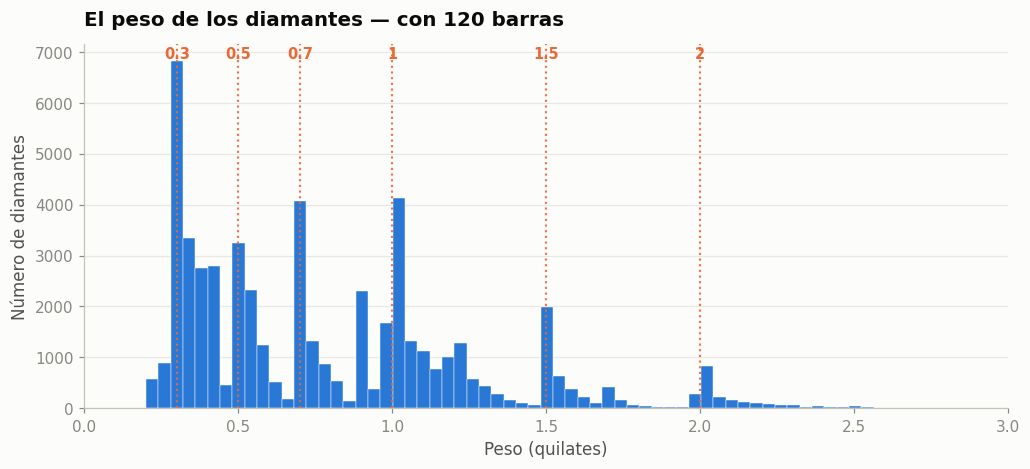

In [21]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.hist(carat, bins=120, color=AZUL, edgecolor="#fcfcfb", linewidth=0.3)

for v in [0.3, 0.5, 0.7, 1.0, 1.5, 2.0]:
    ax.axvline(v, color=NARANJA, linestyle=":", linewidth=1.4, alpha=0.9)
    ax.text(v, ax.get_ylim()[1] * 0.96, f"{v:g}", color=NARANJA, fontsize=9.5,
            fontweight="bold", ha="center")

ax.set_title("El peso de los diamantes — con 120 barras")
ax.set_xlabel("Peso (quilates)")
ax.set_ylabel("Número de diamantes")
ax.set_xlim(0, 3)
ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

🔍 **Nada de eso era continuo.**

La distribución tiene **picos altísimos en los pesos redondos** —0,3; 0,5; 0,7; 1,0; 1,5;
2,0— y huecos justo antes de cada uno. No es una curva suave: es un peine.

La explicación es de mercado, no de geología: un diamante de 0,99 quilates se vende mucho
peor que uno de 1,00, así que **los talladores sacrifican material para llegar al número
redondo**. El hueco a la izquierda de cada pico es el resultado de esa decisión comercial.

**Ninguna de las ocho medidas de la tabla anterior podía revelar esto.** Ni la media, ni la
mediana, ni la desviación, ni los cuartiles. Hacía falta mirar.

In [22]:
# Cuántos diamantes caen justo antes y justo en cada peso redondo
print("El hueco antes del número redondo, en cifras:\n")
for v in [0.5, 1.0, 1.5, 2.0]:
    antes = ((carat >= v - 0.05) & (carat < v)).sum()
    justo = ((carat >= v) & (carat < v + 0.05)).sum()
    print(f"  {v-0.05:.2f}–{v:.2f} quilates: {antes:5,}".replace(",", ".") +
          f"   |   {v:.2f}–{v+0.05:.2f} quilates: {justo:5,}".replace(",", ".") +
          f"   ->  {justo/max(antes,1):.1f} veces más")

El hueco antes del número redondo, en cifras:

  0.45–0.50 quilates:   495   |   0.50–0.55 quilates: 4.536   ->  9.2 veces más
  0.95–1.00 quilates:   281   |   1.00–1.05 quilates: 5.681   ->  20.2 veces más
  1.45–1.50 quilates:    72   |   1.50–1.55 quilates: 2.375   ->  33.0 veces más
  1.95–2.00 quilates:    19   |   2.00–2.05 quilates: 1.090   ->  57.4 veces más


### Y lo que el diagrama de caja habría dicho de todo esto

Nada. Volvamos a dibujar `carat` con los dos gráficos, uno al lado del otro.

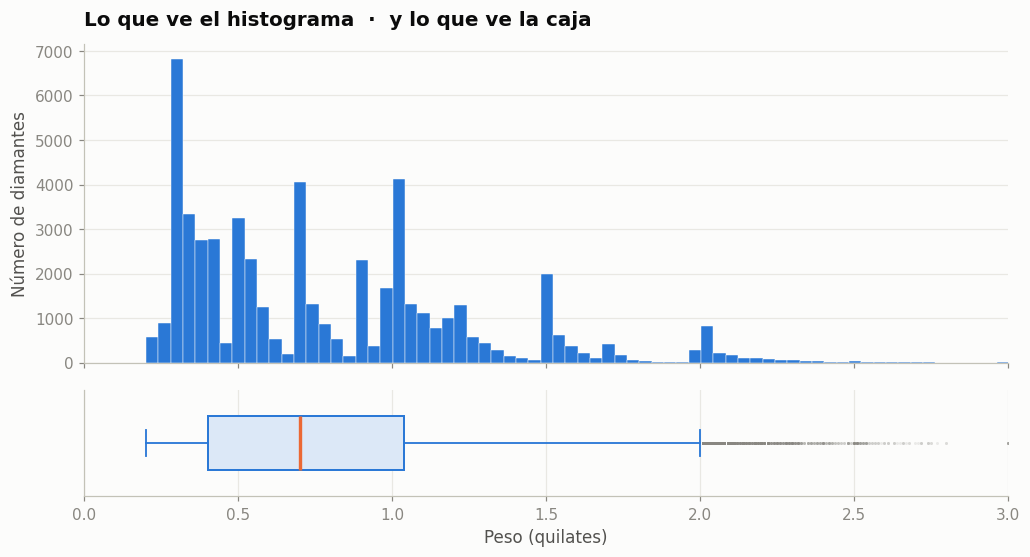

In [23]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9.5, 5.2), sharex=True,
                               gridspec_kw={"height_ratios": [3, 1]})

ax1.hist(carat, bins=120, color=AZUL, edgecolor="#fcfcfb", linewidth=0.3)
ax1.set_title("Lo que ve el histograma  ·  y lo que ve la caja")
ax1.set_ylabel("Número de diamantes")
ax1.grid(axis="y", alpha=0.7); ax1.set_axisbelow(True)

ax2.boxplot(carat, vert=False, widths=0.5, patch_artist=True,
            boxprops=dict(facecolor="#dce8f7", edgecolor=AZUL, linewidth=1.3),
            medianprops=dict(color=NARANJA, linewidth=2.2),
            whiskerprops=dict(color=AZUL, linewidth=1.2),
            capprops=dict(color=AZUL, linewidth=1.2),
            flierprops=dict(marker="o", markersize=2, markerfacecolor=TENUE,
                            markeredgecolor="none", alpha=0.15))
ax2.set_yticks([])
ax2.set_xlabel("Peso (quilates)")
ax2.set_xlim(0, 3)
ax2.grid(axis="x", alpha=0.7); ax2.set_axisbelow(True)

plt.tight_layout()
plt.show()

> **La conclusión del bloque, y la que hay que llevarse de la sesión:**
>
> El diagrama de caja **no puede** mostrar los picos, porque solo conoce cinco números. Una
> distribución con dos modas y una con una sola pueden dar exactamente la misma caja.
>
> Por eso el orden correcto de trabajo es: **histograma primero para ver la forma, caja
> después para comparar grupos.** Nunca la caja sola.

---
---
# Bloque 4 · Las medidas, como complemento

Ahora sí, los números — y su papel exacto: **confirmar o corregir lo que el gráfico
sugirió**, y poner una cifra donde el ojo solo veía una impresión.

## 4.1 · Las tres medidas de centro, y cuándo miente cada una

| Medida | Qué es | Úsala cuando… | Falla cuando… |
|---|---|---|---|
| **Media** | El promedio | La distribución es simétrica y sin extremos | Hay cola larga o atípicos: se va detrás de ellos |
| **Mediana** | El valor del medio | Hay asimetría o atípicos | Necesitas que la suma tenga sentido (totales, presupuestos) |
| **Moda** | El valor más frecuente | La variable es cualitativa, o discreta con picos | La variable es continua: casi no se repite ningún valor |

La relación entre media y mediana es un **diagnóstico de forma** que se calcula en un
segundo, y se puede verificar contra el histograma.

In [24]:
def centro(serie, nombre):
    m, med = serie.mean(), serie.median()
    if m > med * 1.02:   forma = "asimétrica a la DERECHA (cola larga de valores altos)"
    elif m < med * 0.98: forma = "asimétrica a la IZQUIERDA"
    else:                forma = "aproximadamente SIMÉTRICA"
    return {"variable": nombre, "media": round(m, 2), "mediana": round(med, 2),
            "media/mediana": round(m / med, 2), "forma sugerida": forma}

pd.DataFrame([centro(df[c], c) for c in ["price", "carat", "depth", "table"]]).set_index("variable")

,media,mediana,media/mediana,forma sugerida
variable,,,,
price,3932.80,2401.0,1.64,asimétrica a la DERECHA (cola larga de valores...
carat,0.80,0.7,1.14,asimétrica a la DERECHA (cola larga de valores...
depth,61.75,61.8,1.00,aproximadamente SIMÉTRICA
table,57.46,57.0,1.01,aproximadamente SIMÉTRICA


🔍 **Léelo así.** `price` y `carat` tienen la media claramente por encima de la mediana:
cola larga a la derecha, que es justo lo que vimos. `depth` y `table` están casi
equilibradas — y esa es una predicción comprobable.

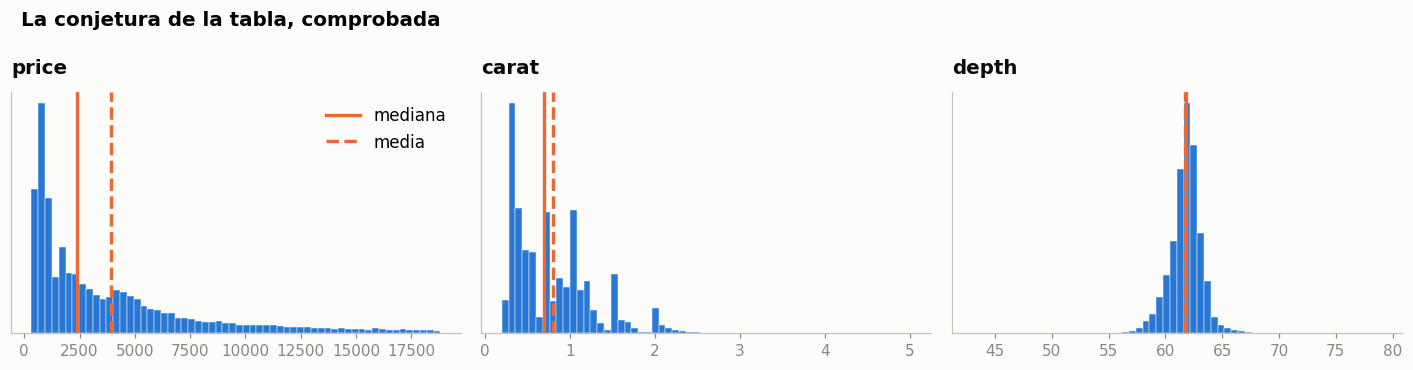

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
for ax, col in zip(axes, ["price", "carat", "depth"]):
    ax.hist(df[col], bins=60, color=AZUL, edgecolor="#fcfcfb", linewidth=0.3)
    ax.axvline(df[col].median(), color=NARANJA, linewidth=2.2, label="mediana")
    ax.axvline(df[col].mean(), color=NARANJA, linewidth=2.2, linestyle="--", label="media")
    ax.set_title(col)
    ax.grid(axis="y", alpha=0.7); ax.set_axisbelow(True)
    ax.set_yticks([])
axes[0].legend(loc="upper right")
fig.suptitle("La conjetura de la tabla, comprobada", fontsize=13, fontweight="bold",
             x=0.02, ha="left")
plt.tight_layout()
plt.show()

En `price` y `carat` la línea punteada (media) queda claramente a la derecha de la sólida
(mediana): la cola la jala. En `depth` las dos se superponen.

## 4.2 · Dispersión: cuatro formas de medir «cuánto varían»

| Medida | Qué mide | Resistente a extremos |
|---|---|---|
| **Rango** | Máximo menos mínimo | No — depende solo de los dos valores más raros |
| **RIC** | El ancho del 50 % central | **Sí** |
| **Desviación estándar** | La distancia típica a la media | No |
| **Coeficiente de variación** | La desviación **en relación con la media** | No |

El coeficiente de variación es el que permite comparar la dispersión de variables medidas
en unidades distintas: dólares con quilates, o kilos con minutos.

In [26]:
def dispersion(serie, nombre):
    q1, q3 = serie.quantile([0.25, 0.75])
    return {"variable": nombre,
            "rango": round(serie.max() - serie.min(), 2),
            "RIC": round(q3 - q1, 2),
            "desv. est.": round(serie.std(), 2),
            "CV %": round(serie.std() / serie.mean() * 100, 1)}

disp = pd.DataFrame([dispersion(df[c], c) for c in ["price", "carat", "depth", "table"]])
disp = disp.set_index("variable").sort_values("CV %", ascending=False)
disp

,rango,RIC,desv. est.,CV %
variable,,,,
price,18497.00,4374.25,3989.44,101.4
carat,4.81,0.64,0.47,59.4
table,52.00,3.00,2.23,3.9
depth,36.00,1.50,1.43,2.3


🔍 **Lo que revela el coeficiente de variación.** `price` y `carat` varían enormemente en
términos relativos; `depth` y `table` casi no varían. Y eso **no se podía ver** comparando
las desviaciones estándar directamente, porque están en unidades distintas.

> Una desviación estándar de 3.989 suena enorme… hasta que sabes que la media es 3.933. Una
> de 1,43 suena pequeña… hasta que sabes que la media es 61,7. **El número solo no dice
> nada; el número relativo sí.**

## 4.3 · Y el resumen completo, en una función

Empaquetamos todo en una función reutilizable — la vas a necesitar en la Entrega 1.

In [27]:
def retrato(serie, nombre=None):
    """Devuelve el retrato numérico completo de una variable cuantitativa."""
    nombre = nombre or serie.name
    q1, q2, q3 = serie.quantile([0.25, 0.50, 0.75])
    return pd.Series({
        "n": int(serie.notna().sum()),
        "media": serie.mean(),
        "mediana": q2,
        "desv. est.": serie.std(),
        "CV %": serie.std() / serie.mean() * 100,
        "mínimo": serie.min(),
        "Q1": q1,
        "Q3": q3,
        "máximo": serie.max(),
        "RIC": q3 - q1,
        "media/mediana": serie.mean() / q2,
    }, name=nombre).round(2)


pd.concat([retrato(df[c]) for c in ["price", "carat", "depth", "table"]], axis=1)

,price,carat,depth,table
n,53940.00,53940.00,53940.00,53940.00
media,3932.80,0.80,61.75,57.46
mediana,2401.00,0.70,61.80,57.00
desv. est.,3989.44,0.47,1.43,2.23
CV %,101.44,59.40,2.32,3.89
mínimo,326.00,0.20,43.00,43.00
Q1,950.00,0.40,61.00,56.00
Q3,5324.25,1.04,62.50,59.00
máximo,18823.00,5.01,79.00,95.00
RIC,4374.25,0.64,1.50,3.00


---
# Cierre

## El mapa, otra vez — ahora con todo lo visto

| Gráfico | Su pregunta | Su punto débil |
|---|---|---|
| **Barras** | ¿Cuántos por categoría? | Ninguno grave, si el eje empieza en cero |
| **Torta** | ¿Qué proporción del total? | El ojo compara ángulos mal |
| **Pareto** | ¿Cuántas categorías cubren el 80 %? | Inútil si el reparto es parejo |
| **Lollipop** | Barras con muchas categorías | Diferencias pequeñas se leen peor |
| **Histograma** | ¿Qué forma tiene? | Depende del ancho de barra que elijas |
| **Densidad** | La forma, suavizada | Inventa datos fuera de los límites reales |
| **Caja** | Centro, dispersión y extremos | **No ve las modas** |
| **Violín** | Forma y resumen a la vez | Necesita explicación; engaña con pocos datos |
| **Puntos** | Cada observación | Ilegible con muchos datos |
| **Acumulada** | ¿Qué proporción está bajo X? | No muestra la forma |

## Las cinco ideas que hay que llevarse

1. **El gráfico se elige por el tipo de variable y por la pregunta**, nunca por costumbre.
2. **En una variable ordinal, el orden de las barras es información.** No lo reordenes por
   frecuencia.
3. **El histograma no es un objeto: es una decisión.** Prueba tres anchos antes de creerle
   a uno.
4. **La caja no ve las modas.** Histograma primero para la forma, caja después para
   comparar grupos.
5. **Los números confirman lo que el gráfico sugiere** — y a veces el gráfico muestra lo que
   ningún número podía, como el peine de `carat`.

---

## 📌 Actividad 3 · 4 % · cuestionario en clase

Diez preguntas cortas: te doy una variable y una pregunta de negocio, y eliges el gráfico
—y justificas en una línea—. También hay lectura de medidas: dada una tabla de resumen,
decir qué forma tiene la distribución.

Se responde en el formulario que comparto al final de la sesión.

---

## Para la sesión 5 · viernes 4 de septiembre · presencial

- **Lee Cleff, capítulos 4 y 5.**
- Mañana seguimos con la misma variable, pero con las preguntas que hoy dejamos abiertas:
  **medidas de forma y posición, robustez frente a valores extremos, detección de atípicos,
  y las escalas y ejes que hacen mentir a un gráfico honesto.**
- **La Entrega 1 es el lunes 7.** Con lo de hoy ya puedes hacer el análisis univariado de
  tus variables clave: usa la función `retrato()` y acompáñala del gráfico que corresponda a
  cada tipo.



---
<small>Fundamentos de estadística para la analítica de datos · Universidad Central ·
Maestría en Analítica de Datos · Grupo 4M · 2026-2 · Diana Angélica Pulido</small>